## Pinwheels is a classical aperiodic tiling introduced by John Conway

https://en.wikipedia.org/wiki/Pinwheel_tiling

In [81]:
#!pip install blue_sampler

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import blue_sampler as blue

def get_transformations():
    return [
        (np.array([[-1,-2],[-2, 1]])/5,  np.array([2/5, 4/5])),  # T1
        (np.array([[ 2,-1],[-1,-2]])/5,  np.array([1/5, 2/5])),  # T2
        (np.array([[ 2, 1],[-1, 2]])/5,  np.array([1/5, 2/5])),  # T3
        (np.array([[ 2,-1],[-1,-2]])/5,  np.array([6/5, 2/5])),  # T4
        (np.array([[-2,-1],[ 1,-2]])/5,  np.array([6/5, 2/5])),  # T5
    ]

def subdivide(triangles):
    """(N,3,2) → (5N,3,2)"""
    result = []
    for M, t in get_transformations():
        result.append(np.einsum('ij,nkj->nki', M, triangles) + t)
    return np.concatenate(result, axis=0)

def show_result(tiling, points):
    fig, ax = plt.subplots(figsize=(10,6), dpi=150)
    ax.set_facecolor('#080c14'); fig.patch.set_facecolor('#080c14')
    n = len(tiling)
    colors = [plt.cm.plasma(0.05 + 0.9*(i%37)/37) for i in range(n)]
    ax.add_collection(PolyCollection(tiling, facecolors=colors,
                                      edgecolors='#080c14', linewidths=0.15, alpha=0.93))
    pts = tiling.reshape(-1,2)
    ax.set_xlim(pts[:,0].min()-0.02, pts[:,0].max()+0.02)
    ax.set_ylim(pts[:,1].min()-0.02, pts[:,1].max()+0.02)
    ax.set_aspect('equal'); ax.axis('off')
    plt.tight_layout(pad=0); plt.show()

    blue.plot(points)
    blue.plot_structure_factor(points)

def tiling_matrix(base, tiling):
    base   = np.asarray(base,   dtype=float)
    tiling = np.asarray(tiling, dtype=float)
    if base.ndim == 2:
        base = base[np.newaxis]          # (1,3,2)

    Q0, Q1, Q2 = base[0, 0], base[0, 1], base[0, 2]       # (2,)
    P0, P1, P2 = tiling[:, 0], tiling[:, 1], tiling[:, 2]  # (N,2)

    A     = np.column_stack([Q1 - Q0, Q2 - Q0])   # (2,2)
    B     = np.stack([P1 - P0, P2 - P0], axis=2)  # (N,2,2)

    M = B @ np.linalg.inv(A)                       # (N,2,2)
    t = P0 - (M @ Q0[:, np.newaxis])[:, :, 0]     # (N,2)

    return M, t


In [83]:
base = np.array([[0.,0.],[2.,0.],[0.,1.]])

tiling = base.copy()[None]

for i in range(5):
    tiling = subdivide(tiling)

tiling = np.concatenate([tiling, -tiling + np.array([[2.0, 1.0]])], axis = 0)
tiling = np.concatenate([tiling, tiling + np.array([[0.0, 1.0]])], axis = 0)

M, t = tiling_matrix(base, tiling)

points0 = blue.tessel2points(base[None], p = 6)[0]
points = np.einsum('nij,kj->nki', M, points0) + t[:, None, :]

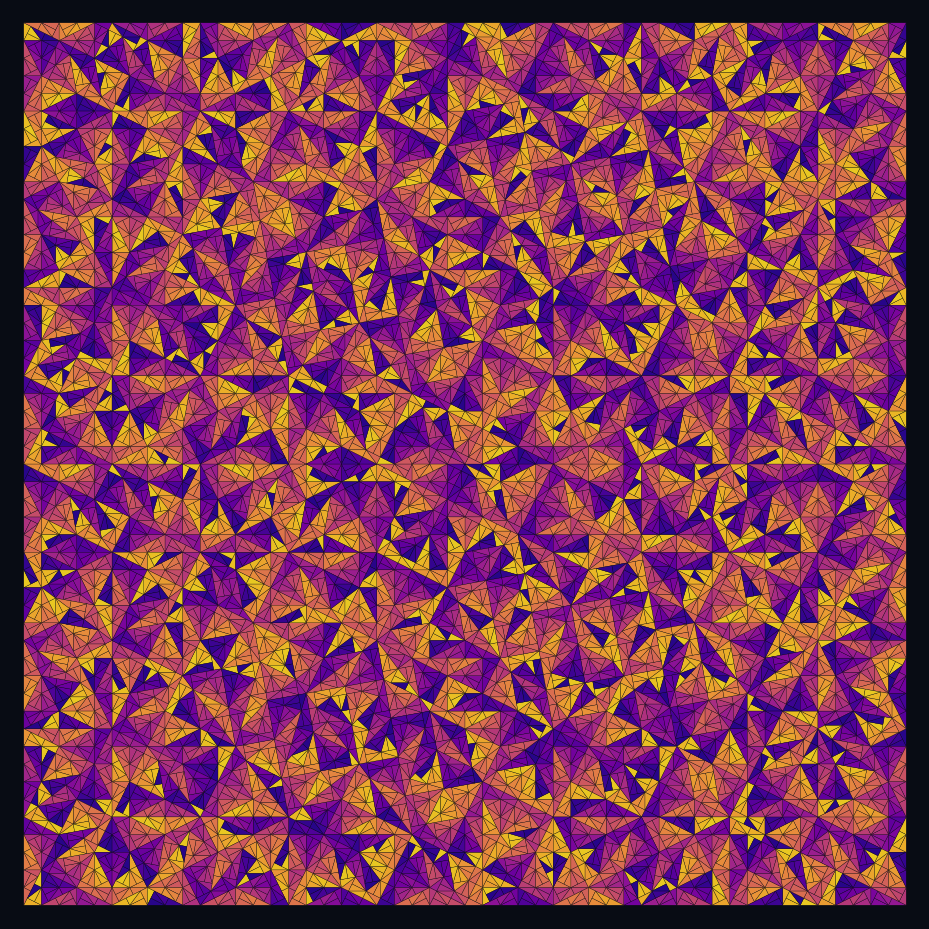

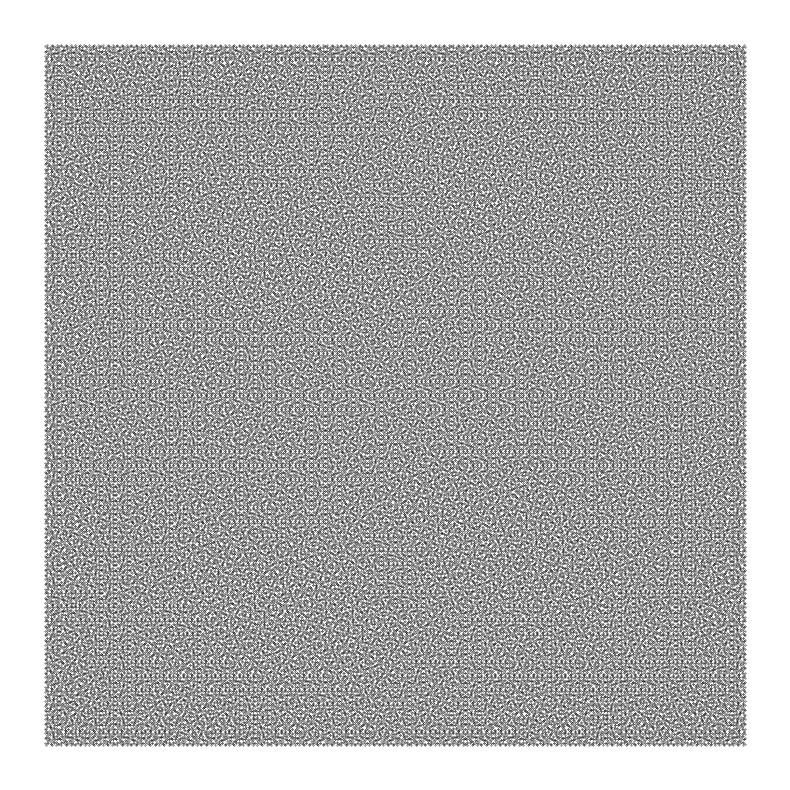

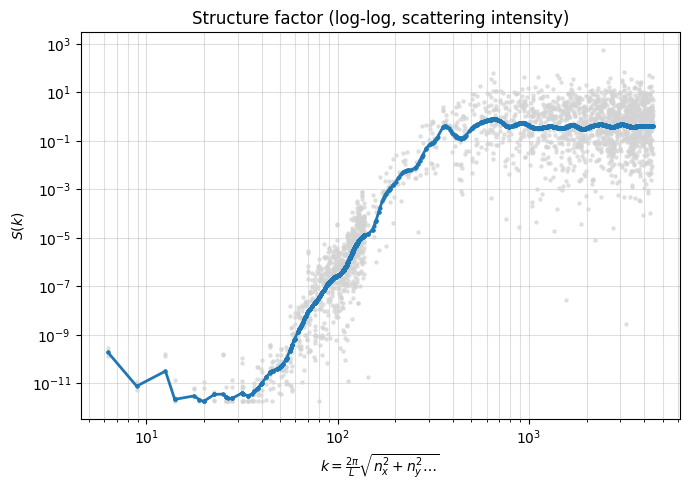

In [84]:
show_result(tiling, points)